In [1]:
"""
fitters_test.ipynb

Tests the fitter object, meant to 
fit all models to a given session.

Author: Stellina X. Ao
Created: 2026-03-05
Last Modified: 2026-03-05
Python Version: 3.11.14
"""

from sg.fitter import *

import scienceplots
import shutup
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# pretty plots
plt.style.use(['nature'])
plt.rcParams['figure.dpi'] = 200
%matplotlib widget
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

# seed and suppress warnings :-)
# fitlvm_utils.seed()
shutup.please()

In [2]:
trial_data_all = np.load("../vars/trial_data_all_MM012_MM013_all5.npz", allow_pickle=True)['arr_0']
session_data_all = np.load("../vars/session_data_all_MM012_MM013_all5.npz", allow_pickle=True)['arr_0']
unit_spike_times_all = np.load("../vars/unit_spike_times_all_MM012_MM013_all5.npz", allow_pickle=True)['arr_0']
regions_all = np.load("../vars/regions_all_MM012_MM013_all5.npz", allow_pickle=True)['arr_0']

subj_idx = 0; sess_idx = 5

unit_spike_times = unit_spike_times_all[subj_idx][sess_idx]
trial_data = trial_data_all[subj_idx][sess_idx]
session_data = session_data_all[subj_idx][sess_idx]
regions = regions_all[subj_idx][sess_idx]
trial_data['block_side'] = np.where(trial_data['block_side'] == 'left', 1, -1)

In [3]:
family = LVMFamily(trial_data=trial_data,
                     spike_times=unit_spike_times,
                     session_data=session_data,
                     regions=regions,
                     n_latents=4)
family.fit_all()

In [4]:
import pickle

with open("../vars/family.pkl", "wb") as f:
    pickle.dump(family, f)

In [5]:
with open("../vars/family.pkl", "rb") as f:
    family = pickle.load(f)

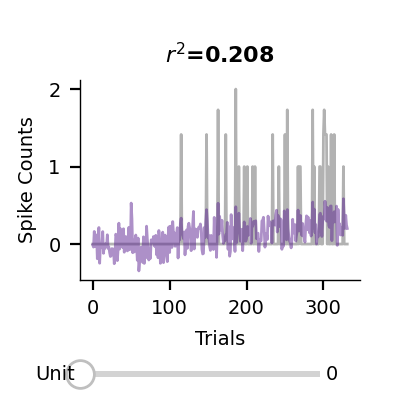

In [8]:
from squiggs.neuron_viewer import *
from squiggs.renderers import *

render_baseline = FitRenderer(family.mod_ae_gain, 
                x=family.test_dl.dataset[:], 
                y=family.test_dl.dataset[:]['robs'].detach().cpu())
nv = NeuronViewer(num_units=render_baseline.y.shape[1], render_func=render_baseline)

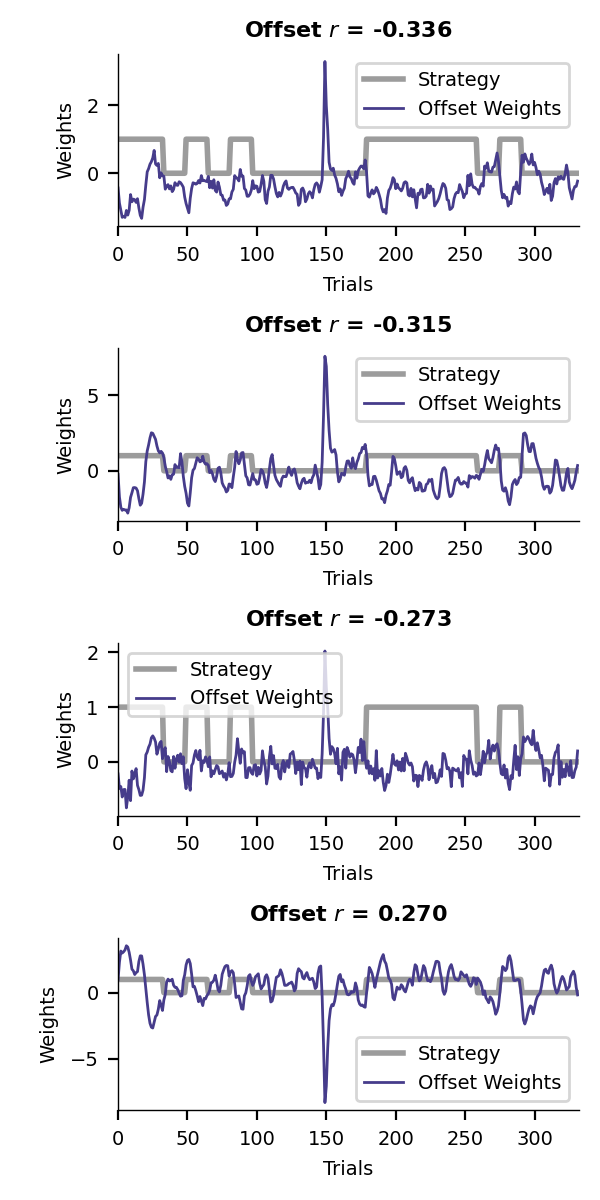

In [7]:
from sg.eval_models import *

plot_summary(family, model=family.mod_offset, potato=family.strategy, mode='offset')